In [1]:
import matplotlib.pyplot as plt
from cubes import get_cube
from utils import profile_and_capture_cpu, profile_and_capture_gpu

In [2]:
device = "cuda"
order = "1"
results = {}

In [3]:
header_mem = " Peak VRAM" if (device == "cuda") else "  Peak RAM"

print(f"|  N  |     DOFs |     Setup | FWD Solve | BWD Solve | {header_mem} |")
print("| --- | -------- | --------- | --------- | --------- | ---------- |")

for N in [10, 20, 30, 40, 50, 60]:
    cmd = ["python", "cubes.py", "-N", str(N), "-device", device, "-order", order]
    if device == "cuda":
        mem_data, internal_clock = profile_and_capture_gpu(cmd)
    else:
        mem_data, internal_clock = profile_and_capture_cpu(cmd)
    mem_usage = [m for _, m in mem_data]
    setup_t = internal_clock["SETUP_DONE"] - internal_clock["START"]
    fwd_t = internal_clock["FWD_DONE"] - internal_clock["SETUP_DONE"]
    bwd_t = internal_clock["BWD_DONE"] - internal_clock["FWD_DONE"]
    peak_mem_mb = max(mem_usage) if mem_usage else 0.0
    print(
        f"| {N:3d} | {3*N**3:8d} | {setup_t:8.2f}s | {fwd_t:8.2f}s | {bwd_t:8.2f}s "
        f"| {peak_mem_mb:8.1f}MB |"
    )
    results[N] = (mem_data, internal_clock)

|  N  |     DOFs |     Setup | FWD Solve | BWD Solve |  Peak VRAM |
| --- | -------- | --------- | --------- | --------- | ---------- |
|  10 |     3000 |     0.24s |     0.50s |     0.68s |     35.7MB |
|  20 |    24000 |     0.25s |     0.59s |     0.74s |    220.3MB |
|  30 |    81000 |     0.24s |     0.99s |     0.99s |    725.2MB |
|  40 |   192000 |     0.26s |     1.69s |     1.47s |   1728.4MB |
|  50 |   375000 |     0.31s |     2.93s |     2.33s |   3406.1MB |
|  60 |   648000 |     0.41s |     4.79s |     3.63s |   6048.4MB |


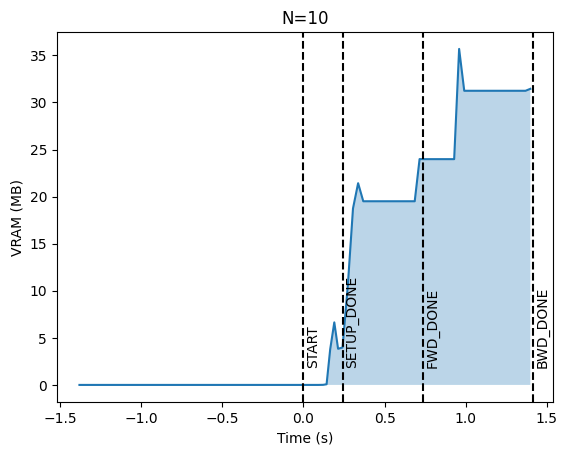

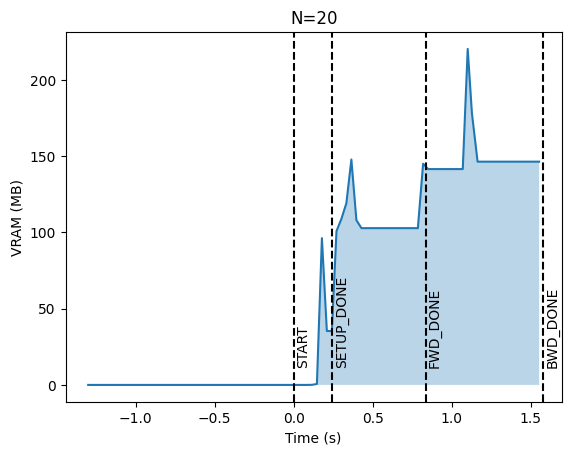

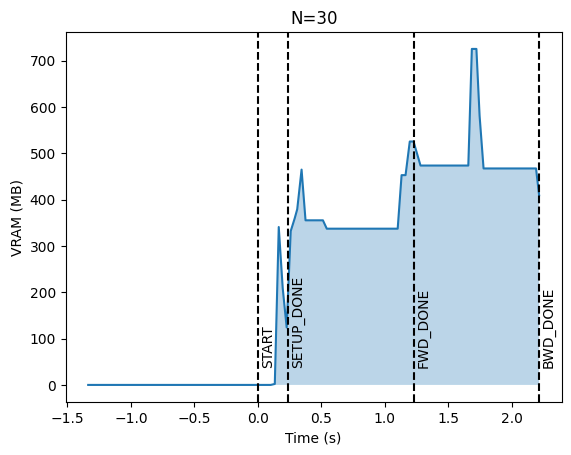

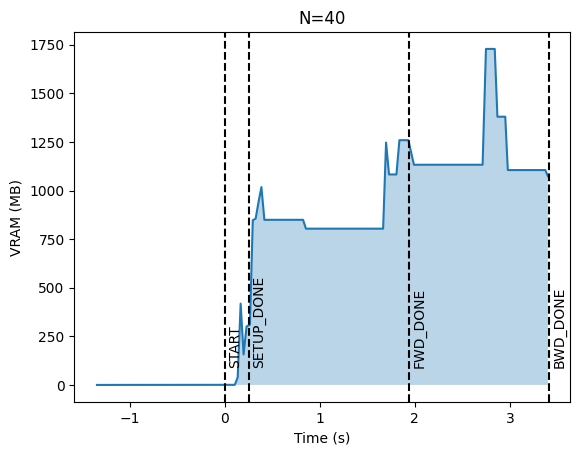

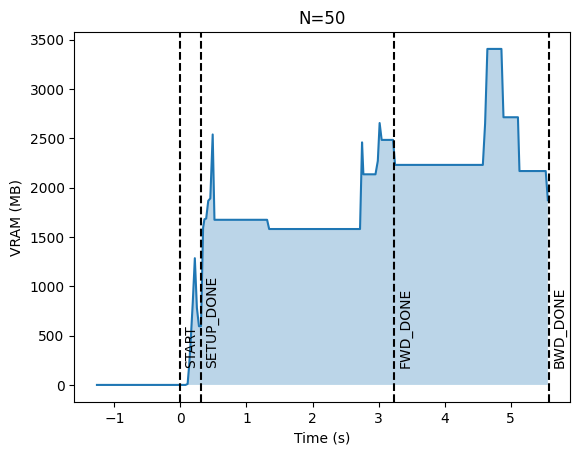

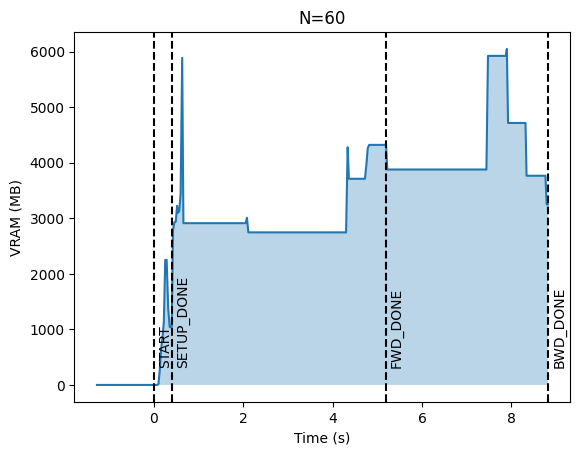

In [4]:
for N, (mem_data, internal_clock) in results.items():
    t0 = internal_clock["START"]
    times = [t - t0 for t, _ in mem_data]
    mem_usage = [m for _, m in mem_data]
    if len(times) == 0:
        continue
    plt.plot(times, mem_usage)
    plt.fill_between(times, mem_usage, alpha=0.3)
    for tag, abs_ts in internal_clock.items():
        if tag not in ["START", "SETUP_DONE", "FWD_DONE", "BWD_DONE"]:
            continue
        relative_ts = abs_ts - t0
        plt.axvline(x=relative_ts, color="black", linestyle="--")
        plt.text(
            relative_ts + 0.01 * max(times),
            0.05 * max(mem_usage),
            tag,
            rotation=90,
            verticalalignment="bottom",
        )
    plt.xlabel("Time (s)")
    plt.ylabel("VRAM (MB)" if device == "cuda" else "RAM (MB)")
    plt.title(f"N={N}")
    plt.show()

In [5]:
import cProfile
import pstats

import torch

torch.set_default_device(device)

def test():
    cube = get_cube(50)
    cube.solve()


cProfile.run("test()", "stats")
p = pstats.Stats("stats")
print(p.sort_stats("time").print_stats(10))

Fri Apr 10 17:49:47 2026    stats

         108805 function calls (108108 primitive calls) in 3.302 seconds

   Ordered by: internal time
   List reduced from 665 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
     2008    1.093    0.001    1.872    0.001 c:\Users\meyernil\.conda\envs\torchfem\Lib\site-packages\torch\utils\_device.py:105(__torch_function__)
      745    0.329    0.000    0.330    0.000 {method 'get' of 'cupy._core.core._ndarray_base' objects}
      6/3    0.226    0.038    0.226    0.075 {method 'mean' of 'torch._C.TensorBase' objects}
      249    0.147    0.001    0.221    0.001 c:\Users\meyernil\.conda\envs\torchfem\Lib\site-packages\cupyx\scipy\sparse\_dia.py:140(tocsc)
        1    0.137    0.137    0.137    0.137 {built-in method cupy_backends.cuda.libs.cusparse.xcoosortByRow}
        1    0.125    0.125    0.125    0.125 {built-in method cupy_backends.cuda.libs.cusparse.gather}
        1    0.114    0.114  

In [6]:
torch.cuda.memory._record_memory_history()

cube = get_cube(60)
solution = cube.solve()

torch.cuda.memory._dump_snapshot("memory_snapshot.pickle")

# Inspect results at https://docs.pytorch.org/memory_viz